In [92]:
import pandas as pd

In [93]:
df = pd.read_csv('spam.csv',  encoding='latin1')

In [94]:
df.shape

(5572, 5)

1. data cleaning
2. EDA
3. text preprocessing
4. model building
5. evaluation


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [96]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace= True)

In [97]:
df.sample(5)

,v1,v2
562,ham,Geeeee ... I love you so much I can barely sta...
1754,ham,How is your schedule next week? I am out of to...
755,ham,So why didnt you holla?
574,ham,Nope i waiting in sch 4 daddy...
2029,ham,Thanx but my birthday is over already.


In [98]:
df.rename(columns={'v1': 'target' , 'v2': 'text'},inplace=True)
df

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [99]:
from sklearn.preprocessing import LabelEncoder 
encoder = LabelEncoder()

In [100]:
df['target'] = encoder.fit_transform(df['target'])

In [101]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [102]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [103]:
df.duplicated().sum()

np.int64(403)

In [104]:
df = df.drop_duplicates(keep='first')

# EDA

In [105]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [106]:
import matplotlib.pyplot as plt

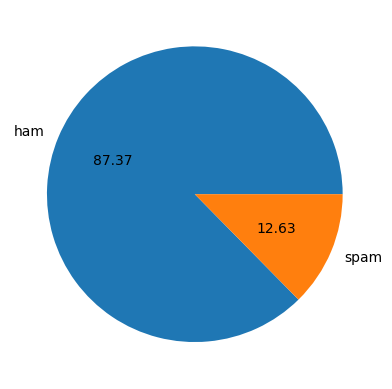

In [107]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'], autopct="%0.2f")
plt.show()

In [108]:
import nltk
print(nltk.data.path)

['C:\\Users\\rithik.singh/nltk_data', 'c:\\Users\\rithik.singh\\vscode\\project\\spamclassifier\\myenv\\nltk_data', 'c:\\Users\\rithik.singh\\vscode\\project\\spamclassifier\\myenv\\share\\nltk_data', 'c:\\Users\\rithik.singh\\vscode\\project\\spamclassifier\\myenv\\lib\\nltk_data', 'C:\\Users\\rithik.singh\\AppData\\Roaming\\nltk_data', 'C:\\nltk_data', 'D:\\nltk_data', 'E:\\nltk_data']


In [109]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rithik.singh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [110]:
df['num_characters'] = df['text'].apply(len)

C:\Users\rithik.singh\AppData\Local\Temp\ipykernel_14168\253964734.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_characters'] = df['text'].apply(len)


In [111]:
df

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161
5568,0,Will Ì_ b going to esplanade fr home?,37
5569,0,"Pity, * was in mood for that. So...any other s...",57
5570,0,The guy did some bitching but I acted like i'd...,125


In [112]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

C:\Users\rithik.singh\AppData\Local\Temp\ipykernel_14168\76344806.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))


In [113]:
df.head(5)

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [114]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

C:\Users\rithik.singh\AppData\Local\Temp\ipykernel_14168\4112269855.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))


In [115]:
df

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [116]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


# ham messages only

In [117]:
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


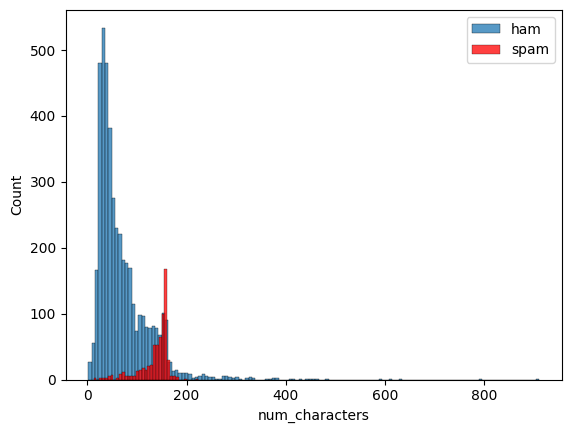

In [118]:
# visualisation
import seaborn as sns

sns.histplot(df[df['target']==0]['num_characters'], label = 'ham')
sns.histplot(df[df['target']==1]['num_characters'],color='red',label ='spam')
plt.legend()


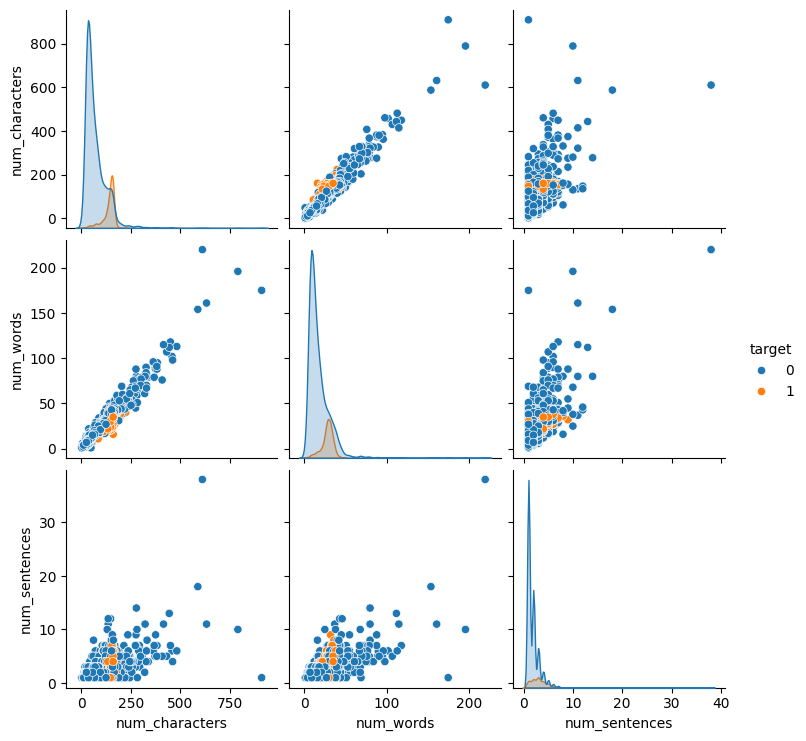

In [119]:
sns.pairplot(df, hue='target')

<Axes: >

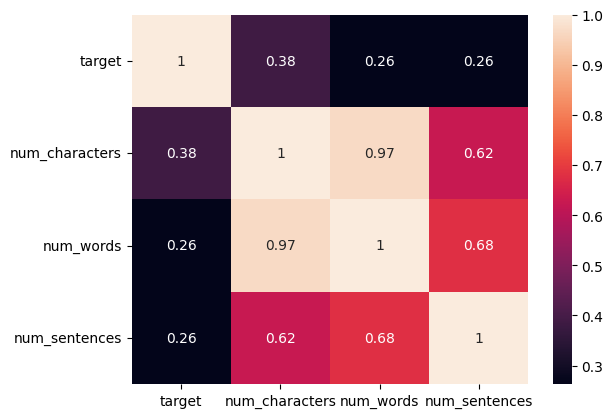

In [120]:
sns.heatmap(df[['target','num_characters','num_words','num_sentences']].corr(),annot=True)

# data preprocessing

In [121]:
# lowercase
# tokenise
# remove special characters like , . $ 
# stopword removal
# punctuation
# stemming

In [122]:
from nltk.corpus import stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rithik.singh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [123]:
stopwords.words('english')
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [124]:
import string

In [125]:
# transform(text) ---------->>apply above methods

In [126]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text) # tokenisation
    
    y = []
    for i in text:
        if i.isalnum():  # checking if i is alphanumeric
            y.append(i)

    text = y[:]
    y.clear()

    for i in text: # stop word removal and punctuation removal
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text : # stemming
        y.append(ps.stem(i))

    return ' '.join(y)

In [127]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [128]:
transform_text("i'm gonna be home soon and i don't want to talk to anyone about it")

'gon na home soon want talk anyon'

In [129]:
df['transformed_text'] = df['text'].apply(transform_text)

C:\Users\rithik.singh\AppData\Local\Temp\ipykernel_14168\283536690.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['transformed_text'] = df['text'].apply(transform_text)


In [130]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [132]:
import wordcloud

In [133]:
from wordcloud import WordCloud

In [140]:
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [141]:
spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep= " "))

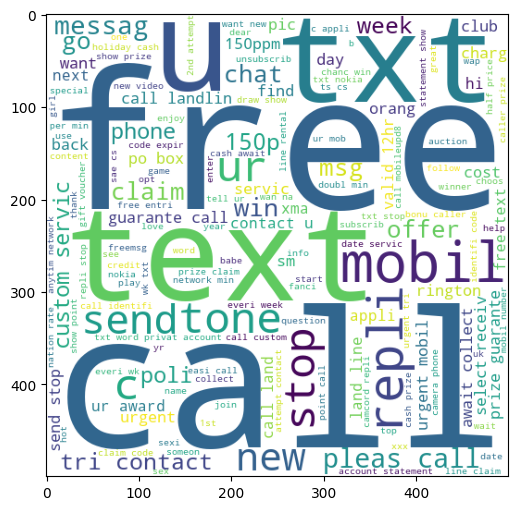

In [143]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

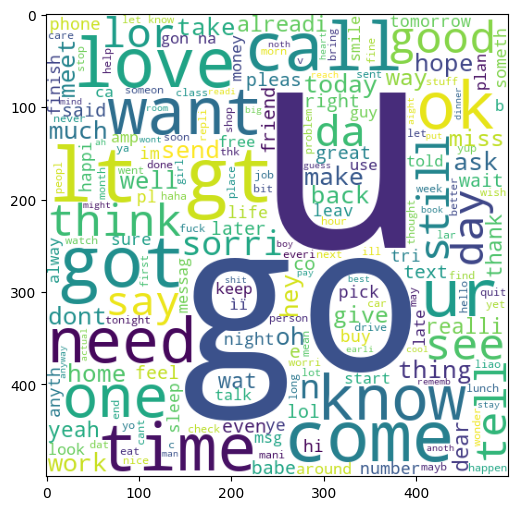

In [144]:
ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep= " "))
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [145]:
spam_corpus = []
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)


In [146]:
len(spam_corpus)

9939

<Axes: xlabel='1', ylabel='0'>

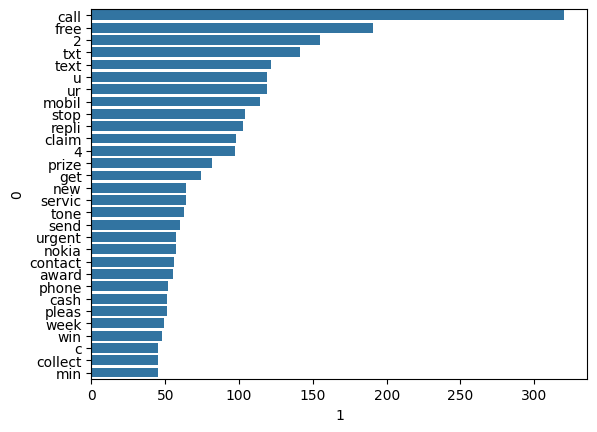

In [156]:
# sns.barplot(x=pd.Series(spam_corpus).value_counts().head(30).values,y=pd.Series(spam_corpus).value_counts().head(30).index)

# sns.barplot(x=pd.DataFrame(spam_corpus)[0].value_counts().head(30).values,y=pd.DataFrame(spam_corpus)[0].value_counts().head(30).index)
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[1],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[0])

In [157]:
ham_corpus = [] 

for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

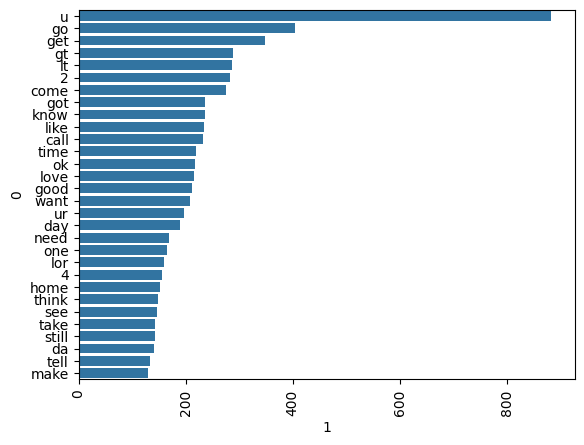

In [162]:
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[1],y=pd.DataFrame(Counter(ham_corpus).most_common(30))[0])
plt.xticks(rotation='vertical')
plt.show()

# model building

In [169]:
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)


In [170]:
x  = tfidf.fit_transform(df['transformed_text']).toarray()

In [171]:
x.shape

(5169, 3000)

In [178]:
y = df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0])

In [179]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score



In [180]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()


In [181]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [182]:
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))


0.8694390715667312
[[772 113]
 [ 22 127]]
0.5291666666666667


In [184]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))


0.9671179883945842
[[885   0]
 [ 34 115]]
1.0


In [185]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9748549323017408
[[884   1]
 [ 25 124]]
0.992


In [186]:
import pickle 

In [187]:
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))